# Exploratory Data Analysis

In [ ]:
import os
import pandas as pd
#import langdetect
import matplotlib.pyplot as plt
from langdetect import detect
import spacy
from sklearn.feature_extraction.text import CountVectorizer

# Parameters

In [2]:
# Paths
path_interim = os.path.join("data", "interim")

# Input
file_input = "prep.csv"

# Load data

In [3]:
path_data_eda = os.path.join(path_interim, file_input)

df_eda = pd.read_csv(path_data_eda)
df_eda.head()

,x_text,y_is_nf
0,Poder crear un usuario y acceder a través de é...,1
1,Poder crear un perfil personal e individual a ...,0
2,Acceder a la aplicación y a sus funcionalidade...,1
3,Todos los datos introducidos podrán ser leídos...,1
4,"Poder leer, eliminar, editar o incluir cualqui...",0


# Check corpus language

In [4]:
# Apply to every example of `x_text` of `df_eda` the appropieate function from `langdetect`
# not every instance may by detected as Spanish, given that the tool is not perfect

df_eda['lang'] = df_eda['x_text'].apply(detect)
df_eda

,x_text,y_is_nf,lang
0,Poder crear un usuario y acceder a través de é...,1,es
1,Poder crear un perfil personal e individual a ...,0,ca
2,Acceder a la aplicación y a sus funcionalidade...,1,es
3,Todos los datos introducidos podrán ser leídos...,1,es
4,"Poder leer, eliminar, editar o incluir cualqui...",0,es
...,...,...,...
384,Gestión de los errores: El asistente debe esta...,0,es
385,Respuestas coherentes e idénticas ante entrada...,0,es
386,Velocidad en las respuestas: El principal serv...,1,es
387,Facilidad de uso: Las preguntas se deben poder...,1,es


In [5]:
# Count values in pct for `df_eda['lang']`
df_eda['lang'].value_counts(normalize=True)

lang
es    0.984576
pt    0.012853
ca    0.002571
Name: proportion, dtype: float64

# Vocabulary frequency

In [6]:
# Helper cell
from unidecode import unidecode
import typing

# Load Spanish language model
nlp = spacy.load('es_core_news_lg')


def tokenizer_lemma_es(text,
                       max_input_len=nlp.max_length,  # 1000000
                       min_token_len= 2,
                       ) -> typing.List[str]:
    doc = nlp(text[:max_input_len])  # truncar el documento de entrada al máximo proporcionado por el modelo de spacy
    lemmas = [unidecode(token.lemma_) for token in doc if token.is_alpha
              and len(token) > min_token_len
              and not token.is_stop
              and not token.like_email
              and not token.like_url
              and not token.is_currency
              and token.ent_type_ not in ['PER', 'LOC', 'ORG']
              ]
    return lemmas # list[str]


example = df_eda.loc[0, "x_text"]
ex_lemma = tokenizer_lemma_es(example)

print(f"{example=}")
print(f"{ex_lemma=}")

# Should see:
# example='Poder crear un usuario y acceder a través de él a la aplicación'
# ex_lemma=['crear', 'usuario', 'acceder', 'aplicacion']


example='Poder crear un usuario y acceder a través de él a la aplicación'
ex_lemma=['crear', 'usuario', 'acceder', 'aplicacion']


In [7]:
cvect_lemma = CountVectorizer(  
    # Use the correct one to get exact term counts
    # Do not remove stopwords
    # use unigrams only
    # Do not discard any frequent/infrequent term in the vocabulary

    tokenizer=tokenizer_lemma_es,
    stop_words=None,
    ngram_range=(1,1),
    min_df=1,
    max_df=1.0
)

# Fit on training data and transform both train and test
dtm = cvect_lemma.fit_transform(df_eda['x_text'])

dtm.shape  # note the number of columns

/home/estebanm/Escritorio/Master/pc4_nlp/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


(389, 950)

In [8]:
# Helper cell: This dataframe should have terms a columns, docs as rows
# and each cell represents the term frequency on the given doc

df_dtm = pd.DataFrame(
    data= dtm.todense(),
    columns= cvect_lemma.get_feature_names_out()
)
    
df_dtm.head(2)

,abanico,abrir,acabar,acceder,accesibl,accesible,acceso,accion,activada,activar,...,vital,volumen,volver,voz,vuelo,web,wifi,word,xss,zona
0,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
# Perform the correct operation on  `df_dtm` to obtain the total term frequency

se_vocab = df_dtm.sum(axis=0)
print(f"{type(se_vocab)=}")  # should be 1-dim (a pandas.Series)
print(f"{se_vocab.shape=}")  # should match DTM number of columns

type(se_vocab)=<class 'pandas.core.series.Series'>
se_vocab.shape=(950,)


In [10]:
se_vocab_srt = se_vocab.sort_values(ascending=False)  # order terms by descending frequency

In [11]:
# total vocab size
len(se_vocab_srt)

950

In [12]:
# number of terms with frequency = 1
len(se_vocab_srt[se_vocab_srt==1])

427

In [13]:
# number of terms with frequency = 2
num_terms_freq_2 = (se_vocab==2).sum()
print(f"Número de términos con frecuencia 2: {num_terms_freq_2}")

Número de términos con frecuencia 2: 151


In [14]:
# number of terms with frequency = < 5

num_terms_freq_5 = (se_vocab<= 5).sum()
print(f"Número de términos con frecuencia 5: {num_terms_freq_5}")

Número de términos con frecuencia 5: 754


In [15]:
# To check how many terms are below a given freq:
se_freq_vals_sizes = se_vocab_srt.value_counts()
se_freq_vals_sizes # n terms ->  obs frequency


1      427
2      151
3       80
4       59
5       37
7       26
6       26
8       19
10      15
9       14
16      12
13       9
15       8
14       7
21       5
17       4
20       4
39       4
29       4
42       3
72       3
11       3
24       2
26       2
30       2
71       2
52       2
22       2
18       2
31       2
19       2
84       1
346      1
63       1
82       1
48       1
59       1
23       1
28       1
32       1
33       1
34       1
12       1
Name: count, dtype: int64

In [16]:
# Top most frequent terms
se_vocab_srt.head(10)

usuario          346
querer            84
aplicacion        82
ruta              72
barco             72
mostrar           72
dato              71
grupo             71
administrador     63
registrado        59
dtype: int64

In [17]:
# Top most infrequent terms
se_vocab_srt.tail(10)

internet           1
interpretacion     1
individualmente    1
informativo        1
infraestructura    1
acabar             1
actor              1
vital              1
volumen            1
wifi               1
dtype: int64

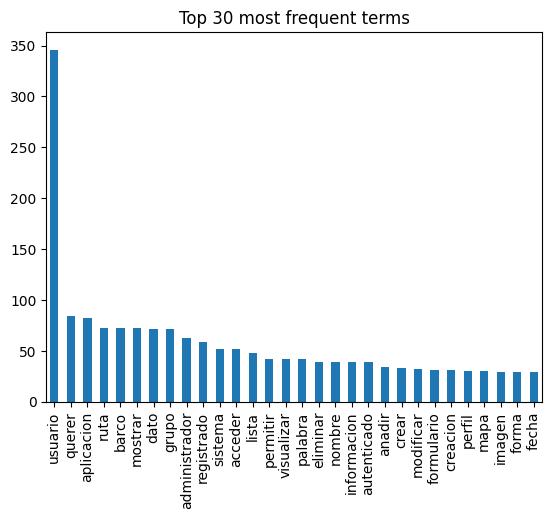

In [37]:
os.makedirs("outputs", exist_ok=True)

ax = se_vocab_srt.head(30).plot.bar(
    title="Top 30 most frequent terms"
)

fig = ax.get_figure()
# save file
plt.savefig("outputs/top_most_freq_terms.png",  bbox_inches='tight', dpi=300)
plt.show()


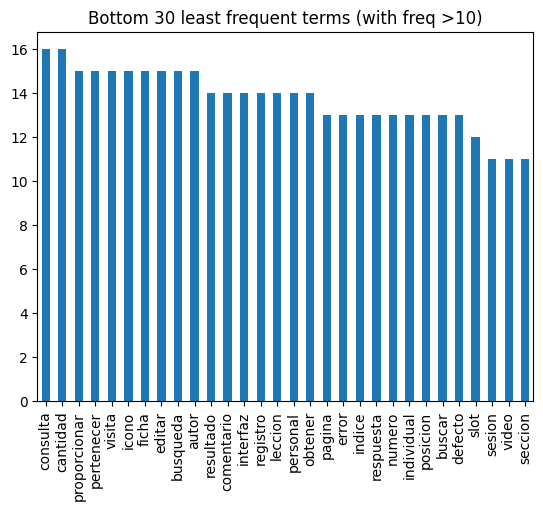

In [38]:
os.makedirs("outputs", exist_ok=True)
mask =  se_vocab_srt > 10 # filter terms with freq below threshold

ax = se_vocab_srt[mask].tail(30).plot.bar(
    title="Bottom 30 least frequent terms (with freq >10)"
)
fig = ax.get_figure()


In [39]:
# save file

fig.savefig("outputs/bottom_least_freq_terms_g10.png", bbox_inches='tight', dpi=300)
plt.show()